In [1]:
from sensor_network_utils import * 

In [2]:
# Load data
flowdata_paths = ['data/dailyflow_v3_1.csv', 'data/dailyflow_v3_2.csv']
df_cleaned, gauges_gdf, flowlines_gdf, usgs_index_df = load_data(
    flowdata_paths,
    'data/gage_12_shpaefile/SWIM_gage_loc_12.shp',
    'data/tx_gulf_flowlines/flowlines.shp',
    'data/gage_12.csv'
)

/opt/homebrew/anaconda3/envs/aorc/lib/python3.11/site-packages/pyogrio/raw.py:198: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D Point' is converted to 'Point Z'
  return ogr_read(


In [3]:
# Prepare USGS indices
usgs_location, usgs_number, columns_to_keep = prepare_usgs_indices(df_cleaned, usgs_index_df)


In [4]:
# Split data
X_train, X_test = split_data(df_cleaned.values)


In [5]:
# Get sensor placement from QR
sensor_location = sensor_placement_qr(X_train, usgs_number)


In [6]:
# Evaluate both configurations
_, recon_opt, _, _, _, _ = reconstruction_evaluation(X_train, X_test, sensor_location, usgs_number)
_, recon_usgs, _, _, _, _ = reconstruction_evaluation(X_train, X_test, usgs_location, usgs_number)


In [7]:
# Calculate performance

_, _, nnse_opt = calculate_performance_metrics(X_test, recon_opt)
_, _, nnse_usgs = calculate_performance_metrics(X_test, recon_usgs)
diff_nnse = nnse_opt - nnse_usgs


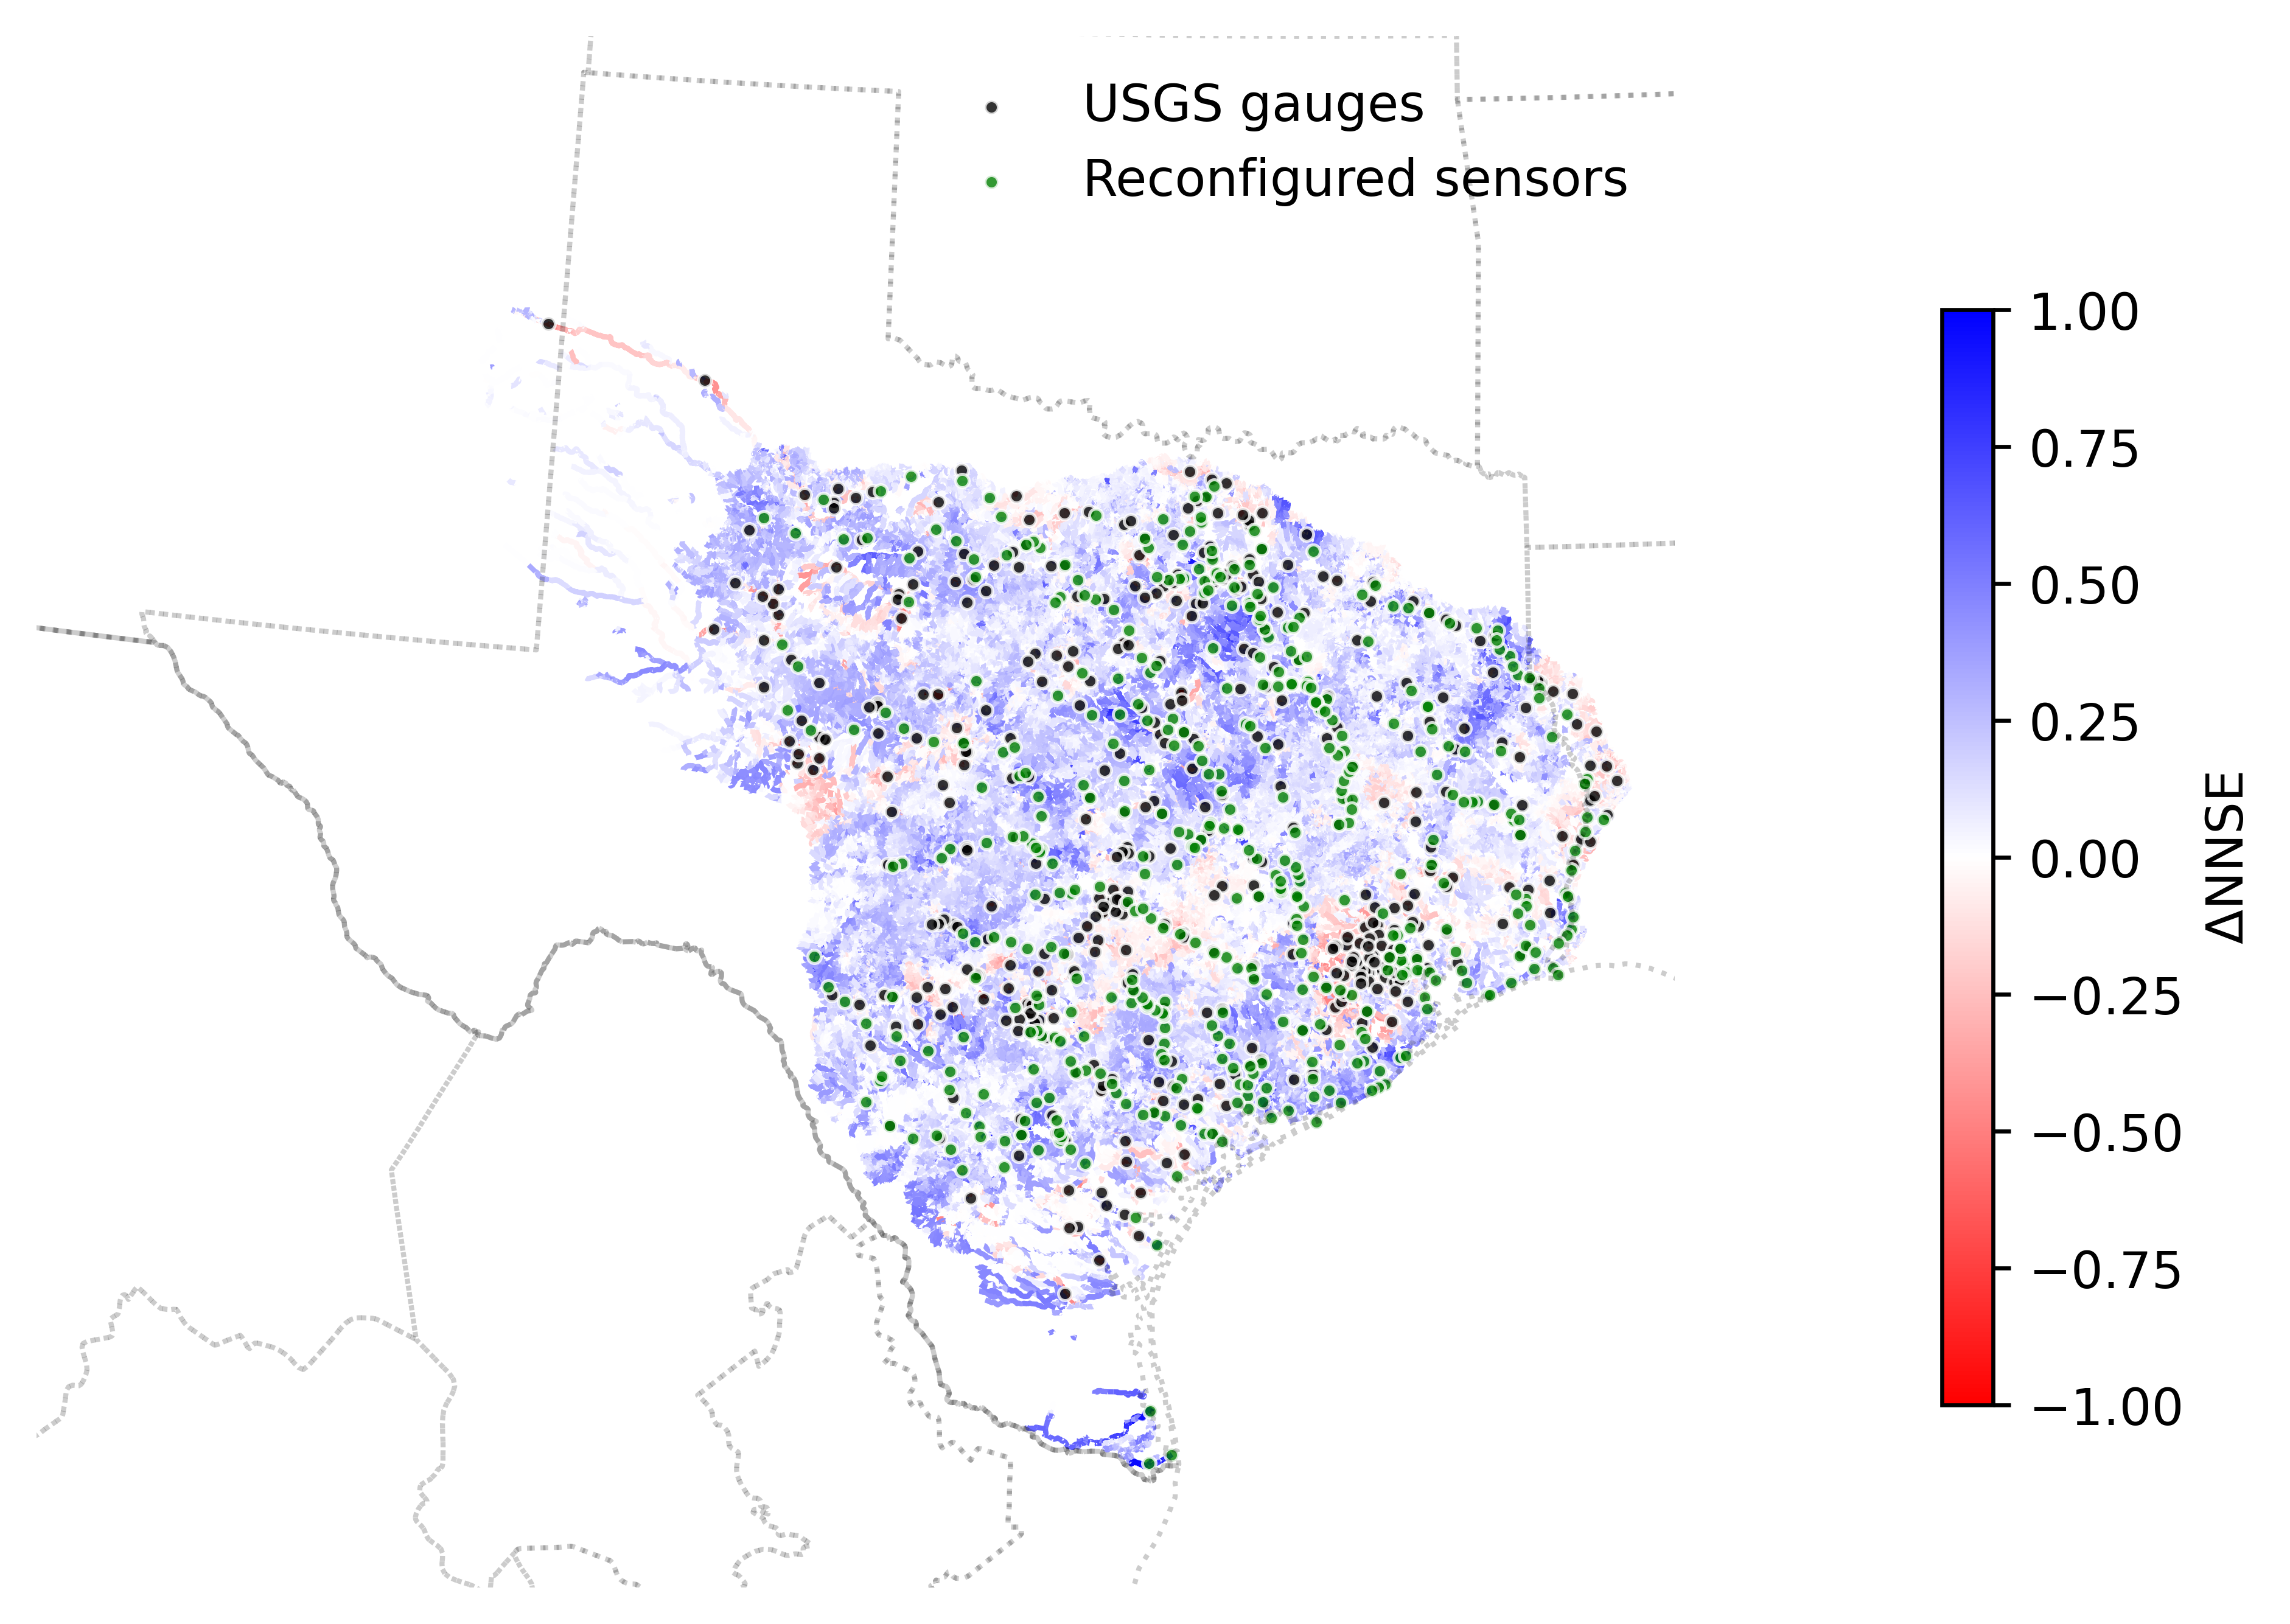

In [8]:
# Visualization

flowlines_with_nnse, centroids = prepare_visualization_data(
    flowlines_gdf, 
    df_cleaned, 
    diff_nnse,
    {'usgs': usgs_location, 'opt': sensor_location},
    usgs_number
)

plot_sensor_network(flowlines_with_nnse, centroids, save_path='sensor_network.png')

In [9]:
import rasterio
import seaborn as sns

In [10]:
def sample_prism(points_gdf, prism_paths):
    pts = points_gdf.copy()

    for var, path in prism_paths.items():
        with rasterio.open(path) as src:
            pts_native = pts.to_crs(src.crs)
            values = [
                v[0] for v in src.sample(
                    zip(pts_native.geometry.x, pts_native.geometry.y)
                )
            ]
            nodata_val = src.nodata if src.nodata is not None else -9999
            vals_arr   = np.where(np.array(values) == nodata_val, np.nan, values)
            pts[var] = vals_arr
    return pts

In [11]:
prism_files = {
    "ppt"  :"data/PRISM_ppt_30yr_normal_800m_annual.tif",
    "tmean":"data/PRISM_tmean_30yr_normal_800m_annual.tif",
    "population":"data/gpw_v4_population_density_rev11_2020_30_sec_2020.tif"
}

all_centroids = (
    pd.concat([centroids["usgs"], centroids["opt"]])
      .drop_duplicates("COMID")
)
all_centroids = sample_prism(all_centroids, prism_files)

centroids["usgs"] = centroids["usgs"].merge(
    all_centroids[["COMID", "ppt", "tmean", "population"]], on="COMID", how="left")
centroids["opt"]  = centroids["opt"].merge(
    all_centroids[["COMID", "ppt", "tmean", "population"]], on="COMID", how="left")

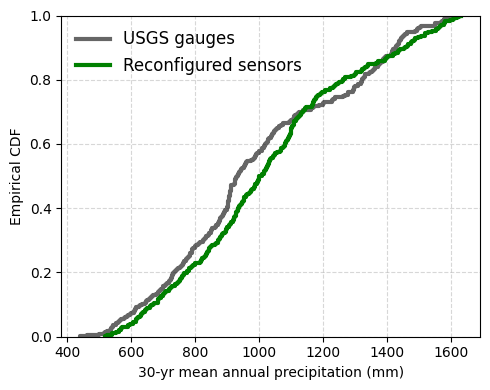

In [12]:
var = "ppt"  
plt.figure(figsize=(5, 4))
sns.ecdfplot(data=centroids["usgs"], x=var, color = 'k', linewidth=3, alpha = 0.6,
             label=f"USGS gauges")
sns.ecdfplot(data=centroids["opt"],  x=var, color = 'green', linewidth=3,
             label=f"Reconfigured sensors")
plt.xlabel("30-yr mean annual precipitation (mm)")
plt.ylabel("Empirical CDF")
plt.legend(frameon=False, fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

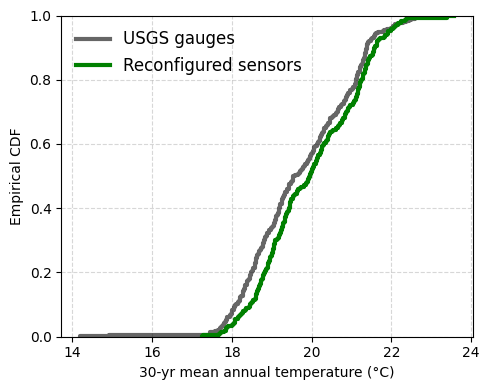

In [13]:
var = "tmean"   
plt.figure(figsize=(5, 4))
sns.ecdfplot(data=centroids["usgs"], x=var, color = 'k', linewidth=3, alpha = 0.6,
             label=f"USGS gauges")
sns.ecdfplot(data=centroids["opt"],  x=var, color = 'green', linewidth=3,
             label=f"Reconfigured sensors")
plt.xlabel("30-yr mean annual temperature (°C)")
plt.ylabel("Empirical CDF")
plt.legend(frameon=False, fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

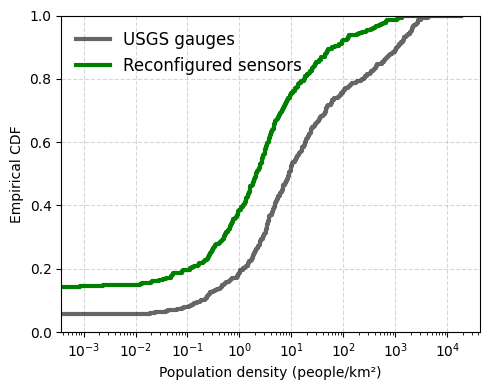

In [14]:
var = "population"   
plt.figure(figsize=(5, 4))
sns.ecdfplot(data=centroids["usgs"], x=var, color = 'k', linewidth=3, alpha = 0.6,
             label=f"USGS gauges")
sns.ecdfplot(data=centroids["opt"],  x=var, color = 'green', linewidth=3,
             label=f"Reconfigured sensors")
plt.xlabel("Population density (people/km²)")
plt.xscale("log")
plt.ylabel("Empirical CDF")
plt.legend(frameon=False, fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

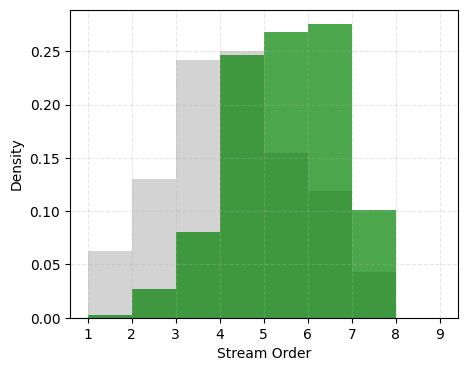

In [15]:
flowlines_gdf.set_index('COMID', inplace=True)
bin_edges = [1, 2, 3, 4, 5, 6, 7, 8, 9]
plt.figure(figsize=(5, 4))
plt.hist(flowlines_gdf.loc[df_cleaned.columns.astype(object)]['StreamOrde'].values[usgs_location[:usgs_number]], bins=bin_edges, density=True, color = 'darkgray', alpha = 0.5)
plt.hist(flowlines_gdf.loc[df_cleaned.columns.astype(object)]['StreamOrde'].values[sensor_location[:usgs_number]], alpha = 0.7, bins=bin_edges, density=True, color = 'green')

plt.xlabel("Stream Order")
plt.ylabel("Density")
plt.grid(linestyle='--', alpha=0.3)
plt.show()

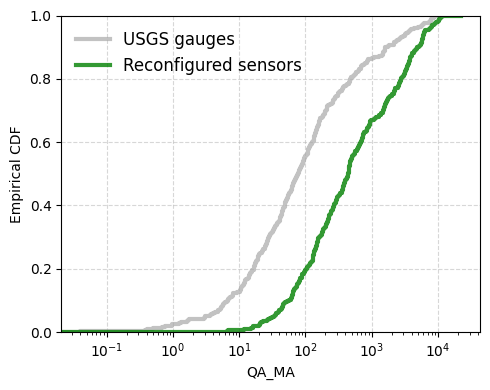

In [16]:
plt.figure(figsize=(5, 4))
sns.ecdfplot(x=flowlines_gdf.loc[df_cleaned.columns.astype(object)]['QA_MA'].values[usgs_location[:usgs_number]], 
             color='darkgray', linewidth=3, alpha=0.7,
             label="USGS gauges")
sns.ecdfplot(x=flowlines_gdf.loc[df_cleaned.columns.astype(object)]['QA_MA'].values[sensor_location[:usgs_number]], 
             color='green', linewidth=3, alpha=0.8,
             label="Reconfigured sensors")

plt.xlabel("QA_MA")
plt.xscale("log")
plt.ylabel("Empirical CDF")
plt.legend(frameon=False, fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

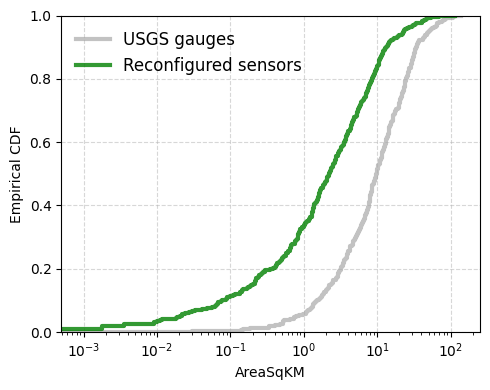

In [17]:
plt.figure(figsize=(5, 4))
sns.ecdfplot(x=flowlines_gdf.loc[df_cleaned.columns.astype(object)]['AreaSqKM'].values[usgs_location[:usgs_number]], 
             color='darkgray', linewidth=3, alpha=0.7,
             label="USGS gauges")
sns.ecdfplot(x=flowlines_gdf.loc[df_cleaned.columns.astype(object)]['AreaSqKM'].values[sensor_location[:usgs_number]], 
             color='green', linewidth=3, alpha=0.8,
             label="Reconfigured sensors")

plt.xlabel("AreaSqKM")
plt.xscale("log")
plt.ylabel("Empirical CDF")
plt.legend(frameon=False, fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [18]:
sensor_location = sensor_placement_qr(X_train, int(X_train.shape[1]*0.2))

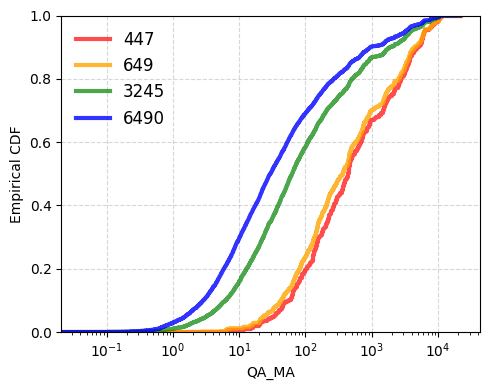

In [19]:
plt.figure(figsize=(5, 4))
sns.ecdfplot(x=flowlines_gdf.loc[df_cleaned.columns.astype(object)]['QA_MA'].values[sensor_location[:usgs_number]], 
             color='red', linewidth=3, alpha=0.7,
             label="447")

sns.ecdfplot(x=flowlines_gdf.loc[df_cleaned.columns.astype(object)]['QA_MA'].values[sensor_location[:int(X_train.shape[1]*0.01)]], 
             color='orange', linewidth=3, alpha=0.8,
             label="649")

sns.ecdfplot(x=flowlines_gdf.loc[df_cleaned.columns.astype(object)]['QA_MA'].values[sensor_location[:int(X_train.shape[1]*0.05)]], 
             color='green', linewidth=3, alpha=0.7,
             label="3245")

sns.ecdfplot(x=flowlines_gdf.loc[df_cleaned.columns.astype(object)]['QA_MA'].values[sensor_location[:int(X_train.shape[1]*0.1)]], 
             color='blue', linewidth=3, alpha=0.8,
             label="6490")

plt.xlabel("QA_MA")
plt.xscale("log")
plt.ylabel("Empirical CDF")
plt.legend(frameon=False, fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

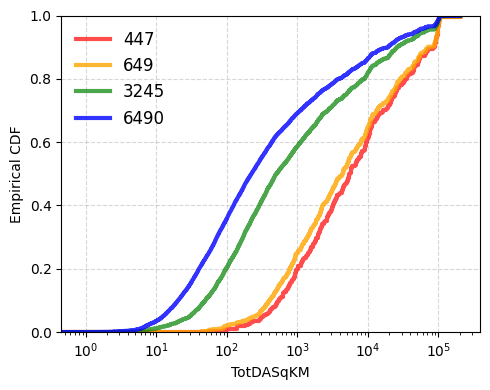

In [20]:
plt.figure(figsize=(5, 4))
sns.ecdfplot(x=flowlines_gdf.loc[df_cleaned.columns.astype(object)]['TotDASqKM'].values[sensor_location[:usgs_number]], 
             color='red', linewidth=3, alpha=0.7,
             label="447")

sns.ecdfplot(x=flowlines_gdf.loc[df_cleaned.columns.astype(object)]['TotDASqKM'].values[sensor_location[:int(X_train.shape[1]*0.01)]], 
             color='orange', linewidth=3, alpha=0.8,
             label="649")

sns.ecdfplot(x=flowlines_gdf.loc[df_cleaned.columns.astype(object)]['TotDASqKM'].values[sensor_location[:int(X_train.shape[1]*0.05)]], 
             color='green', linewidth=3, alpha=0.7,
             label="3245")

sns.ecdfplot(x=flowlines_gdf.loc[df_cleaned.columns.astype(object)]['TotDASqKM'].values[sensor_location[:int(X_train.shape[1]*0.1)]], 
             color='blue', linewidth=3, alpha=0.8,
             label="6490")

plt.xlabel("TotDASqKM")
plt.xscale("log")
plt.ylabel("Empirical CDF")
plt.legend(frameon=False, fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

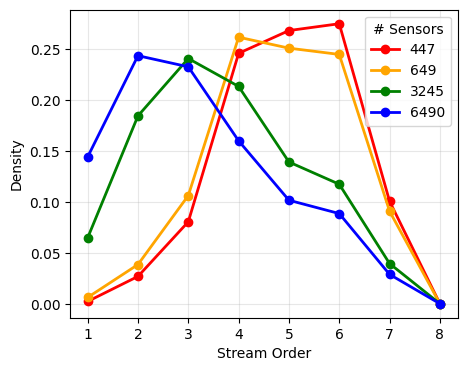

In [21]:
hist_data = flowlines_gdf.loc[df_cleaned.columns.astype(object)]['StreamOrde'].values[sensor_location[:int(usgs_number)]]
hist_data1 = flowlines_gdf.loc[df_cleaned.columns.astype(object)]['StreamOrde'].values[sensor_location[:int(X_train.shape[1]*0.01)]]
hist_data5 = flowlines_gdf.loc[df_cleaned.columns.astype(object)]['StreamOrde'].values[sensor_location[:int(X_train.shape[1]*0.05)]]
hist_data10 = flowlines_gdf.loc[df_cleaned.columns.astype(object)]['StreamOrde'].values[sensor_location[:int(X_train.shape[1]*0.1)]]

datasets = [hist_data, hist_data1, hist_data5, hist_data10]
labels = ["447", "649", "3245", "6490"]
colors = ['red', 'orange', 'green', 'blue']

bin_edges = np.arange(1, 10)
stream_orders = bin_edges[:-1]

fig, ax = plt.subplots(1,1, figsize=(5, 4))

for data, label, color in zip(datasets, labels, colors):
    proportions = []
    for order in stream_orders:
        prop = np.sum(data == order) / len(data)
        proportions.append(prop)
    
    ax.plot(stream_orders, proportions, 'o-', label=label, color=color, 
             linewidth=2, markersize=6)

ax.set_xlabel("Stream Order")
ax.set_ylabel("Density")
ax.set_xticks(stream_orders)
ax.legend(title="# Sensors")
ax.grid(True, alpha=0.3)